# NISAR Access and Exploration in R

**Authors**: Harshini Girish (UAH), Rajat Shinde (UAH), Alex Mandel (Development Seed), Jamison French (Development Seed), Brian Freitag (NASA MSFC), Sheyenne Kirkland (UAH), Henry Rodman (Development Seed), Zac Deziel (Development Seed), Chuck Daniels (Development Seed)

**Date**: March 22, 2026

**Description**: This notebook demonstrates a cloud-native workflow for accessing a NISAR GCOV granule directly from S3 in R, identifying the relevant science layer, defining an area of interest in projected coordinates, clipping the raster to that AOI, and visualizing the resulting subset while avoiding a full local download of the original granule.


## Run This Notebook

To access and run this tutorial within MAAP's Algorithm Development Environment (ADE), please refer to the ["Getting started with the MAAP"](https://docs.maap-project.org/en/latest/getting_started/getting_started.html) section of our documentation.

Disclaimer: it is highly recommended to run a tutorial within MAAP's ADE, which already includes packages specific to MAAP, such as maap-py. Running the tutorial outside of the MAAP ADE may lead to errors. Users should work within the "R/Python" workspace.

## About the Data

This tutorial uses **NISAR Sample L-band products** hosted by ASF/NASA Earthdata. These are **sample datasets** intended to help users practice discovery and access patterns before routine NISAR science products are broadly available.
For this workflow, we focus on the Level-2 Geocoded Polarimetric Covariance (GCOV) sample product. GCOV provides geocoded covariance information (for the available polarization channels) on a map grid, making it well-suited for quick inspection and visualization in Python.
Although these are sample files (not full global-scale operational coverage), they are designed to be structurally compatible with the expected NISAR product format, so the same access and exploration steps can be reused for future NISAR GCOV data.

*Data reference:* [NISAR Sample L-band GCOV granules (Earthdata Search)](https://search.earthdata.nasa.gov/search/granules?p=C3622214170-ASF&pg[0][v]=f&pg[0][gsk]=-start_date)



## Additional Resources
- [NISAR data acccess with Python](https://docs.maap-project.org/en/latest/science/NISAR/NISAR_access.html)
- [GCOV Specs (ASF, evergreen)](https://nisar-docs.asf.alaska.edu/gcov/)
- [xarray Datatree](https://xarray-datatree.readthedocs.io/en/latest/)

## Import and Install Packages

In [ ]:
library(reticulate)
library(terra)
library(ggplot2)
library(dplyr)
library(scales)

## Set up Access

In [2]:
earthaccess <- import("earthaccess")
maap_module  <- import("maap.maap", convert = FALSE)
MAAP         <- maap_module$MAAP
maap         <- MAAP()

## Search and Access 
This cell authenticates with Earthaccess, searches for cloud-hosted NISAR GCOV granules, selects the first returned granule, extracts both the HTTPS and direct S3 access links, requests temporary Earthdata S3 credentials, converts the S3 URL into a GDAL-compatible `/vsis3/` path, and sets the required GDAL environment options so the granule can be accessed directly from cloud storage in R without downloading the full file locally.

In [3]:
earthaccess$login()

results <- earthaccess$search_data(
  short_name = "NISAR_L2_GCOV_BETA_V1",
  count = as.integer(10),
  cloud_hosted = TRUE
)

cat("Granules found:", length(results), "\n")

g <- results[[1]]

https_link <- py_to_r(g$data_links()[[1]])
s3_link    <- py_to_r(g$data_links(access = "direct")[[1]])

asf_s3 <- "https://nisar.asf.earthdatacloud.nasa.gov/s3credentials"
creds  <- py_to_r(maap$aws$earthdata_s3_credentials(asf_s3))

vsis3_path <- sub("^s3://", "/vsis3/", s3_link)

terra::setGDALconfig("AWS_ACCESS_KEY_ID", creds$accessKeyId)
terra::setGDALconfig("AWS_SECRET_ACCESS_KEY", creds$secretAccessKey)
terra::setGDALconfig("AWS_SESSION_TOKEN", creds$sessionToken)
terra::setGDALconfig("AWS_REGION", "us-west-2")
terra::setGDALconfig("AWS_REQUEST_PAYER", "requester")
terra::setGDALconfig("VSI_CACHE", "TRUE")
terra::setGDALconfig("VSI_CACHE_SIZE", "500000000")
terra::setGDALconfig("GDAL_CACHEMAX", "20%")

cat("HTTPS:", https_link, "\n\n")
cat("S3:", s3_link, "\n\n")
cat("GDAL /vsis3/ path:", vsis3_path, "\n")

Granules found: 10 
HTTPS: https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001.h5 

S3: s3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001.h5 

GDAL /vsis3/ path: /vsis3/sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001.h5 


## Inspect Available Subdatasets
This cell opens the NISAR GCOV granule through the GDAL `/vsis3/` cloud path, suppresses non-critical extent mismatch warnings from the HDF5 container structure, lists the available subdatasets, and filters them to locate the `HHHH` science layer that will be used for AOI-based subsetting and visualization in the following steps.

In [4]:
cube <- suppressWarnings(terra::sds(vsis3_path))

data.frame(
  layer = seq_along(names(cube)),
  name = names(cube)
) |>
  dplyr::filter(grepl("HHHH", name))

layer,name
<int>,<chr>
1,HHHH


## Define a AOI for Cropping

This cell identifies the `HHHH` science layer from the available cloud-backed subdatasets, opens that raster for analysis, reads its spatial extent, computes a centered area of interest in projected coordinates, constrains the AOI so it stays within the raster bounds, checks that the resulting AOI is valid, and prints the selected layer name along with the raster and crop extents that will be used in the next step.

In [5]:
hhhh_matches <- grep("^HHHH$|HHHH$", names(cube), value = TRUE)

if (length(hhhh_matches) == 0) {
  stop("Could not find the HHHH layer in the cloud-backed HDF5 subdatasets.")
}

hhhh_name <- hhhh_matches[1]
hhhh <- cube[[which(names(cube) == hhhh_name)[1]]]

r_ext <- terra::ext(hhhh)

x_mid <- (r_ext[1] + r_ext[2]) / 2
y_mid <- (r_ext[3] + r_ext[4]) / 2

aoi_half_size <- 5000

aoi <- terra::ext(
  max(r_ext[1], x_mid - aoi_half_size),
  min(r_ext[2], x_mid + aoi_half_size),
  max(r_ext[3], y_mid - aoi_half_size),
  min(r_ext[4], y_mid + aoi_half_size)
)

if (aoi[1] >= aoi[2] || aoi[3] >= aoi[4]) {
  stop("AOI is invalid after constraining it to the raster extent.")
}

cat("Selected layer:
")
print(hhhh_name)
cat("
Raster extent:
")
print(r_ext)
cat("
AOI extent used for crop:
")
print(aoi)


Warning message:
“[`[`] unknown extent”


Selected layer:
[1] "HHHH"

Raster extent:
SpatExtent : 0, 37080, 0, 36720 (xmin, xmax, ymin, ymax)

AOI extent used for crop:
SpatExtent : 13540, 23540, 13360, 23360 (xmin, xmax, ymin, ymax)


## Read and Visualize 

This cell clips the `hhhh` raster to the area of interest (`aoi`) and first checks that the crop returned data for the selected region. To keep plotting efficient, it optionally aggregates the cropped raster when the number of cells is too large, then converts the raster into a data frame with `x` and `y` coordinates for `ggplot2`. The code extracts valid `HHHH` values, computes the 2nd and 98th percentile range to reduce the effect of extreme outliers, and plots the clipped raster using a continuous color scale. The final map shows the spatial distribution of `HHHH` within the AOI, with axis labels in projected coordinates and a subtitle indicating the aggregation factor used for plotting.

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NISAR GCOV HHHH clipped to projected AOI (2–98%: 0.015–0.677)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NISAR GCOV HHHH clipped to projected AOI (2–98%: 0.015–0.677)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NISAR GCOV HHHH clipped to projected AOI (2–98%: 0.015–0.677)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NISAR GCOV HHHH clipped to projected AOI (2–98%: 0.015–0.677)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NISAR GCOV HHHH clipped to projected AOI (2–98

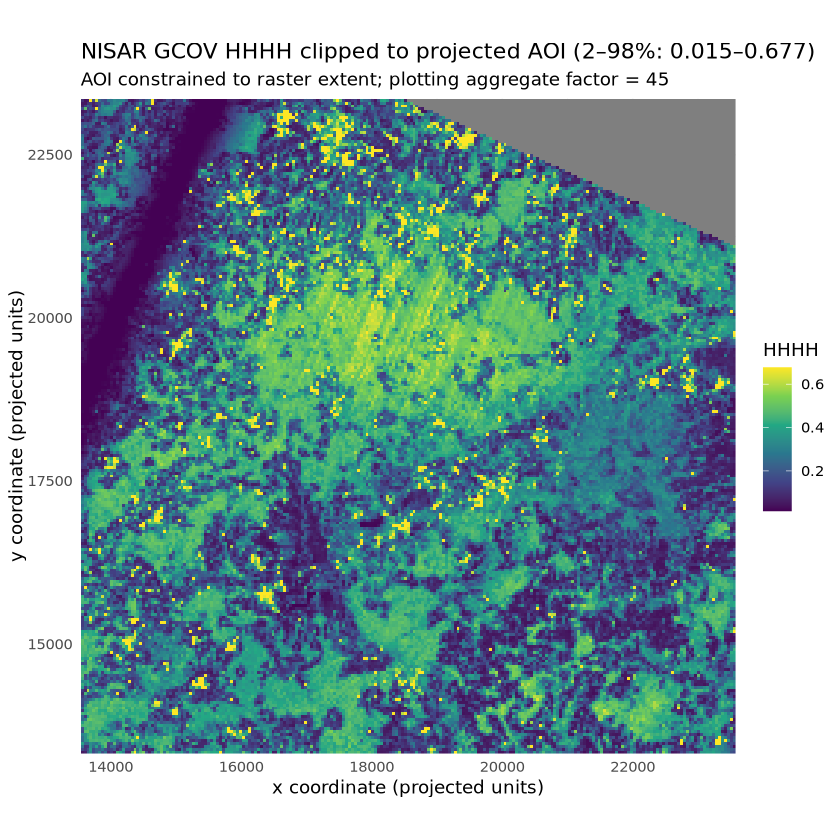

In [8]:
hhhh_subset <- terra::crop(hhhh, aoi, snap = "in")

if (terra::ncell(hhhh_subset) == 0) {
  stop("Crop returned an empty raster. Try a different AOI.")
}

max_plot_cells <- 50000
agg_fact <- max(1, ceiling(sqrt(terra::ncell(hhhh_subset) / max_plot_cells)))

hhhh_plot <- if (agg_fact > 1) {
  terra::aggregate(hhhh_subset, fact = agg_fact, fun = mean, na.rm = TRUE)
} else {
  hhhh_subset
}

plot_df <- as.data.frame(hhhh_plot, xy = TRUE, na.rm = FALSE)
names(plot_df)[3] <- "HHHH"

vals <- plot_df$HHHH[is.finite(plot_df$HHHH)]

if (length(vals) == 0) {
  stop("No finite HHHH values were found in the cropped AOI.")
}

vmin <- as.numeric(quantile(vals, 0.02, na.rm = TRUE))
vmax <- as.numeric(quantile(vals, 0.98, na.rm = TRUE))

ggplot(plot_df, aes(x = x, y = y, fill = HHHH)) +
  geom_raster() +
  coord_equal(expand = FALSE) +
  scale_fill_viridis_c(
    limits = c(vmin, vmax),
    oob = scales::squish
  ) +
  labs(
    title = sprintf(
      "NISAR GCOV HHHH clipped to projected AOI (2–98%%: %.3g–%.3g)",
      vmin, vmax
    ),
    subtitle = sprintf("AOI constrained to raster extent; plotting aggregate factor = %d", agg_fact),
    x = "x coordinate (projected units)",
    y = "y coordinate (projected units)",
    fill = "HHHH"
  ) +
  theme_minimal()

**Note**:If your workflow is taking too long due to the download process, consider using the Python workflow instead. Refer [NISAR Access and Exploration notebook](https://docs.maap-project.org/en/latest/science/NISAR/Simulated_NISAR.html).